<a href="https://colab.research.google.com/github/vascosio1114/ggr376-cafeto-spatial-analysis/blob/main/GGR376_Group15_Proposal_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# 0) Setup & Imports
# ==========================================
# Install required spatial analysis packages
!pip -q install geopandas libpysal esda mapclassify openpyxl splot spopt scikit-learn

# Suppress warnings for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

# Core libraries for spatial and tabular data handling
import geopandas as gpd
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Spatial weights and autocorrelation analysis
from libpysal import weights
from esda.moran import Moran, Moran_Local
from splot.esda import plot_moran

In [ ]:
# ==========================================
# 1) Load Data
# ==========================================

# Load Toronto neighbourhood boundary polygons
# These polygons define the spatial units (neighbourhoods) used in the analysis
nbhd = gpd.read_file(
    'https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/'
    'fc443770-ef0a-4025-9c2c-2cb558bfab00/resource/'
    '02ac940a-98b4-4b00-b04f-5899f24e1ef4/download/'
    'Neighbourhoods%20-%204326.zip'
)

# Basic information about the dataset
print("Neighbourhood dataset loaded")
print("Number of neighbourhoods and attributes:", nbhd.shape)
print("Key columns:", nbhd.columns.tolist())
print("Coordinate Reference System (CRS):", nbhd.crs)

Neighbourhood dataset loaded
Number of neighbourhoods and attributes: (158, 12)
Key columns: ['_id1', 'AREA_ID2', 'AREA_AT3', 'PARENT_4', 'AREA_SH5', 'AREA_LO6', 'AREA_NA7', 'AREA_DE8', 'CLASSIF9', 'CLASSIF10', 'OBJECTI11', 'geometry']
Coordinate Reference System (CRS): EPSG:4326


In [ ]:
# Load CaféTO permit location data (point dataset)
# Each point represents one CaféTO permit location
cafe = gpd.read_file(
    'https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/'
    '3b605a2e-f3bf-4b2b-b972-c0829b2788f5/resource/'
    'a4e9642e-959f-4db8-aa69-0892a74d96fa/download/'
    'Cafe%20TO%20Locations%20-%204326.zip'
)

# Basic information about CaféTO dataset
print("CaféTO locations dataset loaded")
print("Number of records and attributes:", cafe.shape)
print("Coordinate Reference System (CRS):", cafe.crs)

CaféTO locations dataset loaded
Number of records and attributes: (1281, 13)
Coordinate Reference System (CRS): EPSG:4326


In [ ]:
# Load neighbourhood socioeconomic profile data (2021 Census)
profile_raw = pd.read_excel(
    'https://ckan0.cf.opendata.inter.prod-toronto.ca/dataset/'
    '6e19a90f-971c-46b3-852c-0c48c436d1fc/resource/'
    '19d4a806-7385-4889-acf2-256f1e079060/download/'
    'neighbourhood-profiles-2021-158-model.xlsx',
    header=0
)

# Reshape the dataset: set neighbourhood name as index and transpose
# This converts the table into a format suitable for merging later
profile_raw = profile_raw.set_index("Neighbourhood Name").T

# Basic information about the dataset
print("Neighbourhood profile dataset loaded")
print("Dataset shape (rows, columns):", profile_raw.shape)
print("Sample column names:", profile_raw.columns.tolist()[:30])
print("Preview of data:")
print(profile_raw.iloc[:5, :10])

Neighbourhood profile dataset loaded
Dataset shape (rows, columns): (158, 2603)
Sample column names: ['Neighbourhood Number', 'TSNS 2020 Designation', 'Total - Age groups of the population - 25% sample data', '  0 to 14 years', '    0 to 4 years', '    5 to 9 years', '    10 to 14 years', '  15 to 64 years', '    15 to 19 years', '    20 to 24 years', '    25 to 29 years', '    30 to 34 years', '    35 to 39 years', '    40 to 44 years', '    45 to 49 years', '    50 to 54 years', '    55 to 59 years', '    60 to 64 years', '  65 years and over', '    65 to 69 years', '    70 to 74 years', '    75 to 79 years', '    80 to 84 years', '    85 years and over', '      85 to 89 years', '      90 to 94 years', '      95 to 99 years', '      100 years and over', 'Total - Distribution (%) of the population by broad age groups - 25% sample data', '  0 to 14 years']
Preview of data:
Neighbourhood Name                Neighbourhood Number  \
West Humber-Clairville                               1  

In [ ]:
# ==========================================
# 2) Clean & Standardize CRS
# ==========================================

# Reproject all spatial datasets to a common CRS (UTM Zone 17N, EPSG:32617)
# This ensures spatial operations (e.g., distance, area, joins) are accurate
nbhd = nbhd.to_crs(epsg=32617)
cafe = cafe.to_crs(epsg=32617)

# Remove records with missing geometry to avoid errors in spatial analysis
cafe = cafe[cafe.geometry.notna()].copy()

# Verify CRS after transformation
print("Neighbourhood CRS:", nbhd.crs)
print("CaféTO CRS:", cafe.crs)

Neighbourhood CRS: EPSG:32617
CaféTO CRS: EPSG:32617


In [ ]:
# Spatial join: assign each CaféTO point to a neighbourhood polygon
# Use 'intersects' instead of 'within' to avoid missing boundary points
joined = gpd.sjoin(
    cafe,
    nbhd[['geometry', 'AREA_NA7']],
    how='left',
    predicate='intersects'
)

# Count number of CaféTO permits in each neighbourhood
cafe_count = joined.groupby('AREA_NA7').size().reset_index(name='cafe_count')

# Output results (keep original format)
print('Neighbourhoods with at least 1 CaféTO:', len(cafe_count))
cafe_count.sort_values('cafe_count', ascending=False).head(10)

Neighbourhoods with at least 1 CaféTO: 126


,AREA_NA7,cafe_count
106,Wellington Place,129
57,Kensington-Chinatown,57
3,Annex,49
103,Trinity-Bellwoods,48
120,Yonge-Bay Corridor,48
95,South Riverdale,38
96,St Lawrence-East Bayfront-The Islands,34
83,Palmerston-Little Italy,34
30,Downtown Yonge East,30
44,Harbourfront-CityPlace,28


In [ ]:
# Extract population and median income variables from the profile dataset
nbhd_names = profile_raw.index.tolist()

# Helper function: extract one variable by keyword from the transposed profile table
def extract_row(df, keyword):
    matches = [c for c in df.columns if keyword.lower() in str(c).lower()]
    if len(matches) == 0:
        raise KeyError(f"No column contains keyword: {keyword}")
    s = pd.to_numeric(df[matches[0]], errors="coerce")
    s.index = nbhd_names
    return s

# Extract population and median household income
pop_series    = extract_row(profile_raw, 'Total - Age')
income_series = extract_row(profile_raw, 'Median total income of household')

# Create a neighbourhood-level socioeconomic table
socio = pd.DataFrame({
    'AREA_NA7'     : nbhd_names,
    'population'   : pop_series.values,
    'median_income': income_series.values
})

# Fix mismatched neighbourhood names before merging
name_mapping = {
    'Cabbagetown-South St. James Town': 'Cabbagetown-South St.James Town',
    'Danforth-East York':               'Danforth East York',
    'East End Danforth':                'East End-Danforth',
    'North St. James Town':             'North St.James Town',
    'O`Connor Parkview':                "O'Connor-Parkview",
    'Taylor Massey':                    'Taylor-Massey',
    'Yonge-St. Clair':                  'Yonge-St.Clair'
}

socio['AREA_NA7'] = socio['AREA_NA7'].replace(name_mapping)
print('Mismatches after fix:', len(set(nbhd['AREA_NA7']) - set(socio['AREA_NA7'])))
socio.head()

Mismatches after fix: 0


,AREA_NA7,population,median_income
0,West Humber-Clairville,33300,92000
1,Mount Olive-Silverstone-Jamestown,31345,76500
2,Thistletown-Beaumond Heights,9850,86000
3,Rexdale-Kipling,10375,77000
4,Elms-Old Rexdale,9355,82000


In [ ]:
# Merge all datasets into a single GeoDataFrame
# Combine neighbourhood boundaries, café counts, and socioeconomic data
db = nbhd.merge(cafe_count, on='AREA_NA7', how='left')
db = db.merge(socio,        on='AREA_NA7', how='left')

# Fill missing values: neighbourhoods with no CaféTO permits → 0
db['cafe_count'] = db['cafe_count'].fillna(0)

# Create main analysis variable: CaféTO permits per 1,000 residents
# This standardizes permit counts by population size
db['cafe_per1000'] = np.where(
    db['population'] > 0,
    db['cafe_count'] / db['population'] * 1000,
    np.nan
)

# Output dataset structure and preview
print(db.shape)
db[['AREA_NA7', 'cafe_count', 'cafe_per1000', 'population', 'median_income']].head()

(158, 16)


,AREA_NA7,cafe_count,cafe_per1000,population,median_income
0,South Eglinton-Davisville,17.0,0.747746,22735,80000
1,North Toronto,16.0,1.007240,15885,70000
2,Dovercourt Village,11.0,0.888530,12380,87000
3,Junction-Wallace Emerson,19.0,0.819672,23180,84000
4,Yonge-Bay Corridor,48.0,3.795967,12645,68500


In [ ]:
# ==========================================
# 3) Preliminary ESDA (For Proposal)
# ==========================================

# Generate descriptive statistics for key variables
# This provides an overview of central tendency and variation
print(db[['cafe_per1000', 'population', 'median_income']].describe())

       cafe_per1000    population  median_income
count    158.000000    158.000000     158.000000
mean       0.487285  17476.518987   88968.987342
std        0.804289   6131.717523   23059.153790
min        0.000000   6260.000000   57200.000000
25%        0.059333  12456.250000   76500.000000
50%        0.194323  16812.500000   84500.000000
75%        0.532943  22212.500000   94750.000000
max        5.044975  33300.000000  222000.000000


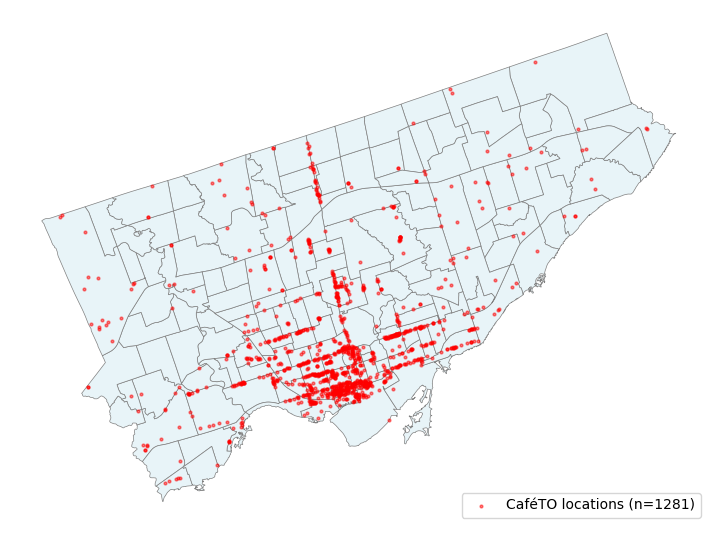

In [ ]:
# Figure 1: Study area map
# Visualize Toronto neighbourhood boundaries with CaféTO permit locations
# This provides an initial overview of the spatial distribution
f, ax = plt.subplots(1, figsize=(9, 9))

db.plot(
    ax=ax,
    color='#e8f4f8',
    edgecolor='grey',
    linewidth=0.5
)

cafe.plot(
    ax=ax,
    color='red',
    markersize=4,
    alpha=0.5,
    label=f'CaféTO locations (n={len(cafe)})'
)

# Remove axis for cleaner map visualization
ax.set_axis_off()

# Add legend to identify CaféTO locations
ax.legend(loc='lower right')

# Save figure for report or presentation use
plt.savefig('fig1_study_area.png', dpi=150, bbox_inches='tight')

# Display the figure
plt.show()

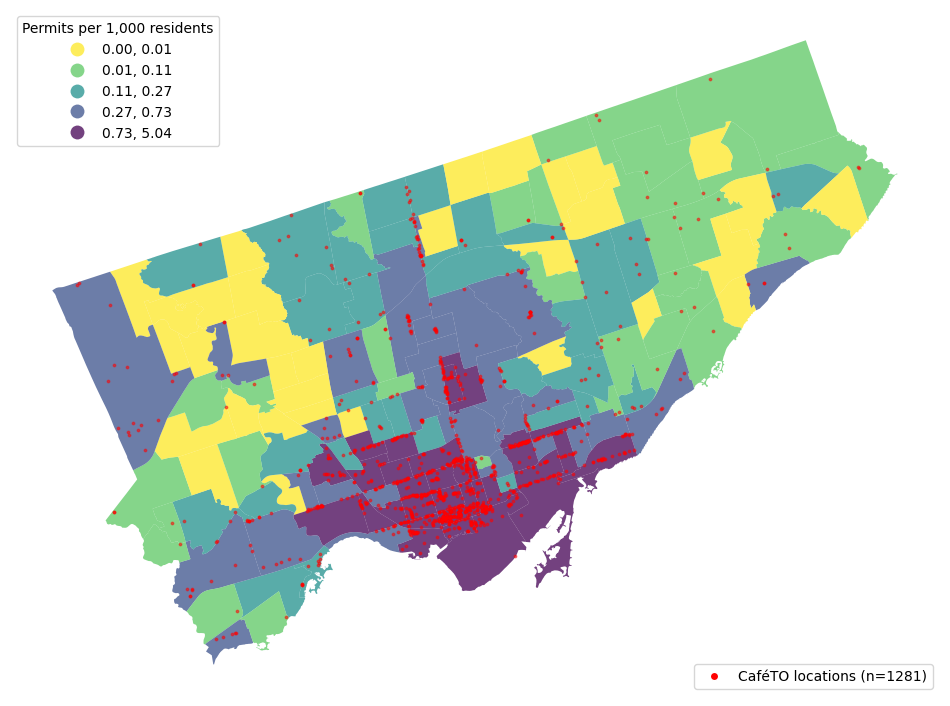

In [ ]:
# Figure 2: Choropleth map of CaféTO permit density
# Visualize permits per 1,000 residents using quantile classification
# Overlay CaféTO point locations for comparison
f, ax = plt.subplots(1, figsize=(12, 12))  # larger figure size for better visibility

db.plot(
    column='cafe_per1000',
    cmap='viridis_r',
    scheme='quantiles',
    k=5,
    edgecolor='white',
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds={
        'loc': 'upper left',
        'title': 'Permits per 1,000 residents',
        'fmt': '{:.2f}'
    },
    ax=ax
)

# Plot CaféTO locations on top of choropleth
cafe.plot(
    ax=ax,
    color='red',
    markersize=3,
    alpha=0.5,
    label=f'CaféTO locations (n={len(cafe)})'
)

# Save choropleth legend before adding point legend
choropleth_legend = ax.get_legend()

# Add a separate legend for CaféTO point locations
from matplotlib.lines import Line2D
point_legend = ax.legend(
    handles=[Line2D([0], [0], marker='o', color='w',
                    markerfacecolor='red', markersize=6,
                    label=f'CaféTO locations (n={len(cafe)})')],
    loc='lower right'
)

# Re-add the choropleth legend (so both legends are shown)
ax.add_artist(choropleth_legend)

# Remove axis for cleaner map visualization
ax.set_axis_off()

# Save figure for report or presentation
plt.savefig('fig2_choropleth_density.png', dpi=150, bbox_inches='tight')

# Display the figure
plt.show()

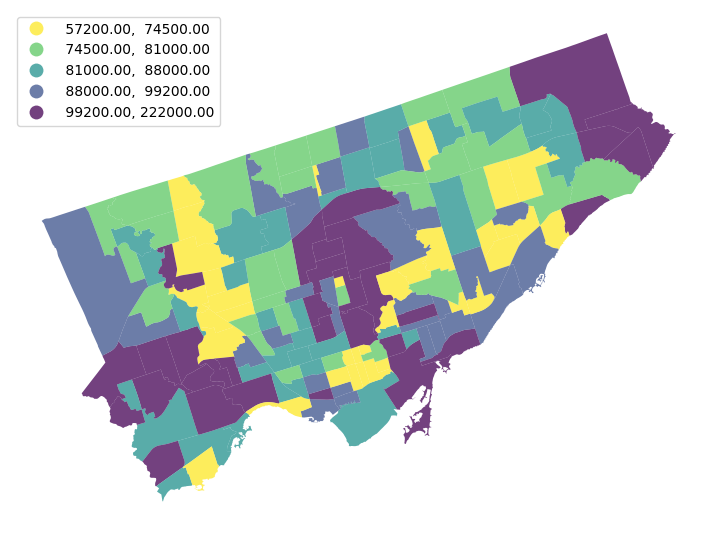

In [ ]:
# Figure 3: Choropleth map of median household income
# Visualize income distribution across neighbourhoods using quantile classification
# This map will later be compared with CaféTO permit density
f, ax = plt.subplots(1, figsize=(9, 9))

db.plot(
    column='median_income',
    cmap='viridis_r',
    scheme='quantiles',
    k=5,
    edgecolor='white',
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds={'loc': 2},
    ax=ax
)

# Remove axis for cleaner map visualization
ax.set_axis_off()

# Save figure for report or presentation
plt.savefig('fig3_choropleth_income.png', dpi=150, bbox_inches='tight')

# Display the figure
plt.show()

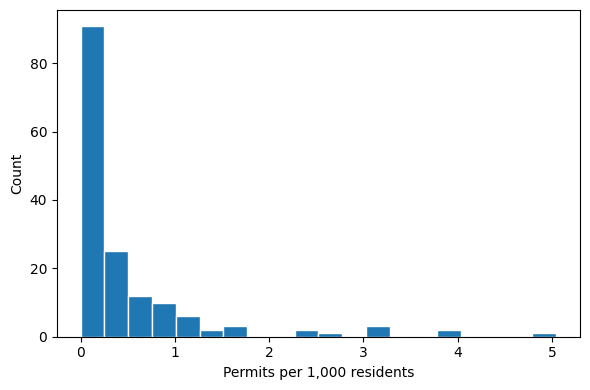

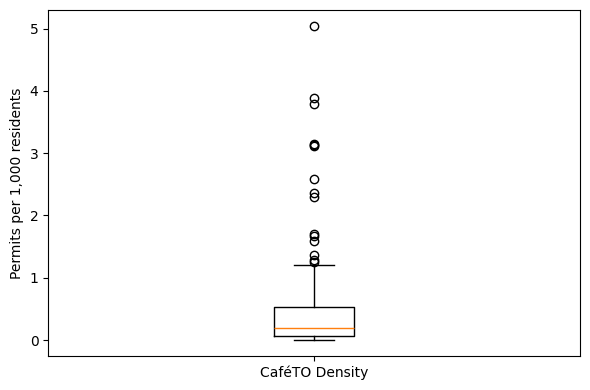

In [ ]:
# Figure 4: Distribution of CaféTO permit density
# Prepare data by removing missing values
data = db['cafe_per1000'].dropna()

# --- Histogram ---
# Visualize the frequency distribution of CaféTO density
plt.figure(figsize=(6, 4))
plt.hist(data, bins=20, edgecolor='white')
plt.xlabel('Permits per 1,000 residents')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('fig4_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Boxplot ---
# Summarize distribution using median, spread, and potential outliers
plt.figure(figsize=(6, 4))
plt.boxplot(data)
plt.ylabel('Permits per 1,000 residents')
plt.xticks([1], ['CaféTO Density'])
plt.tight_layout()
plt.savefig('fig4_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

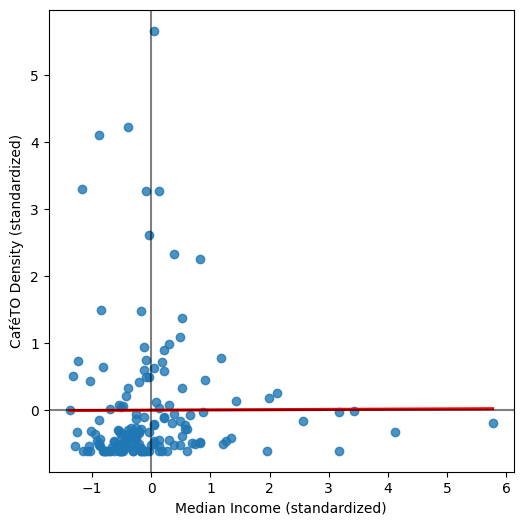

In [ ]:
# Figure 5: Scatterplot of CaféTO density vs. median income
# Standardize variables (z-scores) to make them comparable
import seaborn

db['cafe_per1000_std'] = (
    (db['cafe_per1000'] - db['cafe_per1000'].mean()) /
    db['cafe_per1000'].std()
)

db['median_income_std'] = (
    (db['median_income'] - db['median_income'].mean()) /
    db['median_income'].std()
)

# Create scatterplot with linear regression line
f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x='median_income_std',
    y='cafe_per1000_std',
    ci=None,
    data=db,
    line_kws={'color': 'r'}
)

# Add reference lines at zero (mean values after standardization)
ax.axvline(0, c='k', alpha=0.5)
ax.axhline(0, c='k', alpha=0.5)

# Set axis labels
ax.set_xlabel('Median Income (standardized)')
ax.set_ylabel('CaféTO Density (standardized)')

# Save and display figure
plt.savefig('fig5_scatter_income.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ==========================================
# 4.2) Spatial Autocorrelation
# ==========================================

# Prepare dataset: remove missing values for CaféTO density
db_moran = db.dropna(subset=['cafe_per1000']).copy()

# Create spatial weights matrix using Queen contiguity
# This defines neighbourhood relationships based on shared boundaries or vertices
w_moran = weights.Queen.from_dataframe(db_moran)
w_moran.transform = 'R'  # row-standardization

# Compute Global Moran's I for CaféTO density
# This measures overall spatial autocorrelation (clustering vs randomness)
moran = Moran(db_moran['cafe_per1000'], w_moran)

# Output results
print("Moran's I:", moran.I)
print('p-value (perm):', moran.p_sim)

Moran's I: 0.5998326517463177
p-value (perm): 0.001


In [ ]:
# 4.3 Local Spatial Autocorrelation (LISA)

# Prepare dataset: remove missing values for CaféTO density
db_lisa = db.dropna(subset=['cafe_per1000']).copy()

# Create spatial weights matrix using Queen contiguity
w_lisa = weights.Queen.from_dataframe(db_lisa)
w_lisa.transform = 'R'  # row-standardization

# Standardize CaféTO density (z-score)
# This is used to interpret high/low values relative to the mean
db_lisa['cafe_std'] = (
    db_lisa['cafe_per1000'] - db_lisa['cafe_per1000'].mean()
) / db_lisa['cafe_per1000'].std()

# Compute Local Moran's I (LISA)
# This identifies local clusters and spatial outliers
lisa = Moran_Local(db_lisa['cafe_per1000'], w_lisa)

# Extract cluster categories and significance
db_lisa['lisa_cluster'] = lisa.q
db_lisa['p_value'] = lisa.p_sim
db_lisa['significant'] = db_lisa['p_value'] < 0.05

# Initialize final cluster classification
db_lisa['lisa_final'] = 0

# Assign significant clusters
db_lisa.loc[(db_lisa['lisa_cluster']==1) & (db_lisa['significant']), 'lisa_final'] = 1
db_lisa.loc[(db_lisa['lisa_cluster']==2) & (db_lisa['significant']), 'lisa_final'] = 2
db_lisa.loc[(db_lisa['lisa_cluster']==3) & (db_lisa['significant']), 'lisa_final'] = 3
db_lisa.loc[(db_lisa['lisa_cluster']==4) & (db_lisa['significant']), 'lisa_final'] = 4

# Define labels for each cluster type
lisa_labels = {
    0: 'not significant',
    1: 'High-High',
    2: 'Low-High',
    3: 'Low-Low',
    4: 'High-Low'
}

# Map cluster labels to each neighbourhood
db_lisa['lisa_label'] = db_lisa['lisa_final'].map(lisa_labels)

# Output cluster counts
print(db_lisa['lisa_label'].value_counts())

lisa_label
not significant    94
Low-Low            40
High-High          19
Low-High            3
High-Low            2
Name: count, dtype: int64


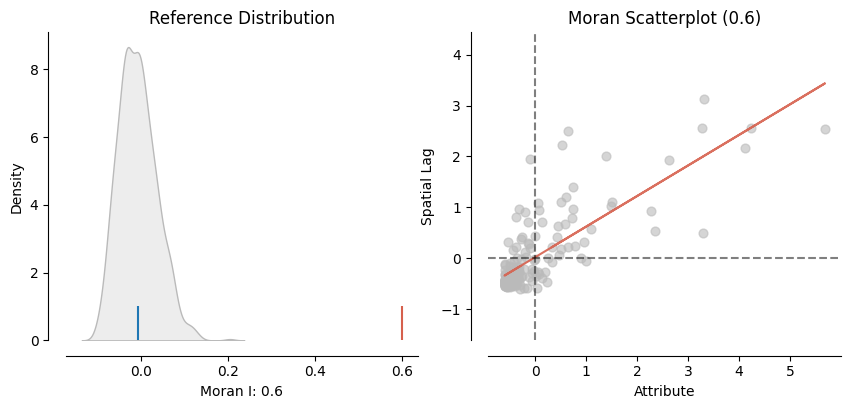

In [ ]:
# Figure 6: Moran scatterplot
# Visualize the relationship between values and spatially lagged values
# The slope of the line corresponds to Moran’s I
plot_moran(moran)

# Display the figure
plt.show()

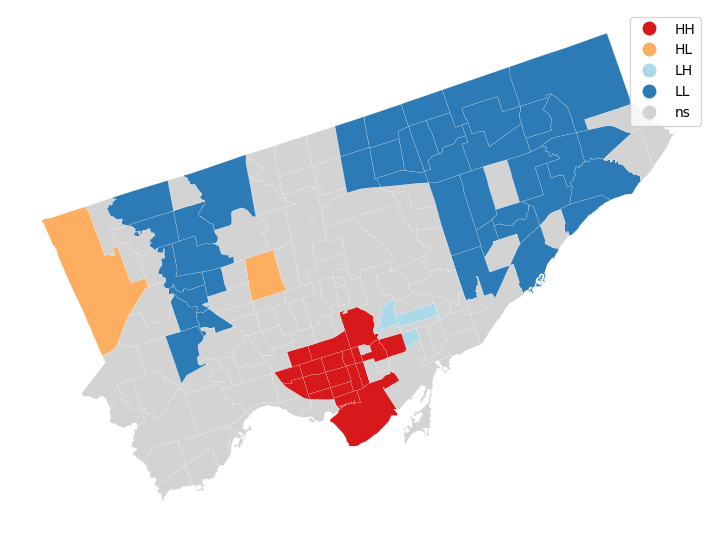

In [ ]:
# Figure 7: LISA cluster map
# Visualize local spatial clusters and outliers of CaféTO density
# Significant clusters are identified at p < 0.05
from splot import esda as esdaplot

f, ax = plt.subplots(1, figsize=(9, 9))

esdaplot.lisa_cluster(
    lisa,
    db_lisa,
    p=0.05,
    ax=ax
)

# Remove axis for cleaner map visualization
ax.set_axis_off()

# Save figure for report or presentation
plt.savefig('fig7_lisa_cluster.png', dpi=150, bbox_inches='tight')

# Display the figure
plt.show()

In [ ]:
print('Zero CaféTO neighbourhoods:', (db['cafe_count'] == 0).sum())
print('Total neighbourhoods:', len(db))

Zero CaféTO neighbourhoods: 32
Total neighbourhoods: 158


In [ ]:
print('Islands:', len(w.islands))

Islands: 0


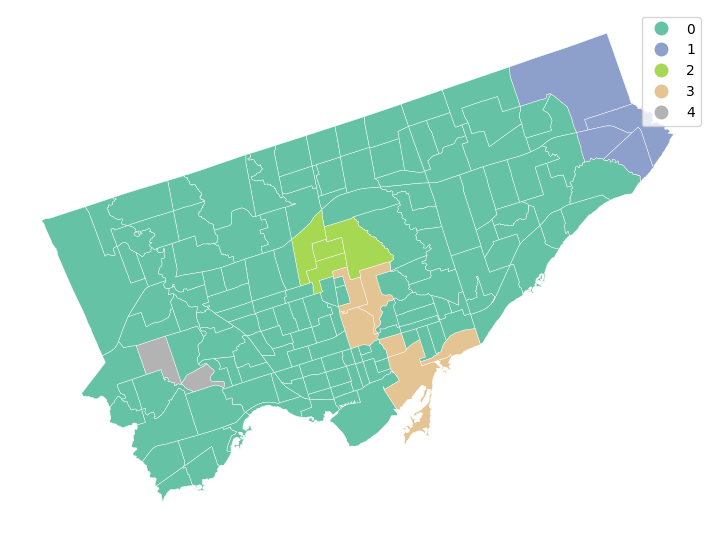

              cafe_per1000  median_income
skater_label                             
0                 0.478285   83388.028169
1                 0.083842  119750.000000
2                 0.478171  171750.000000
3                 1.100092  117333.333333
4                 0.112931  173000.000000


In [ ]:
# Spatially constrained clustering using SKATER
from spopt.region import Skater
from sklearn.preprocessing import StandardScaler

# Select variables for clustering
# These variables represent CaféTO density and neighbourhood income
attrs = ['cafe_per1000', 'median_income']

# Apply SKATER clustering (spatially constrained)
# This groups neighbouring areas into contiguous clusters with similar attributes
model = Skater(db_moran, w_moran, attrs_name=attrs, n_clusters=5)
model.solve()

# Assign cluster labels to each neighbourhood
db_moran['skater_label'] = model.labels_

# Plot clustering results
fig, ax = plt.subplots(1, figsize=(9, 9))
db_moran.plot(
    column='skater_label',
    categorical=True,
    legend=True,
    ax=ax,
    cmap='Set2',
    edgecolor='white',
    linewidth=0.3
)

# Remove axis for cleaner map visualization
ax.set_axis_off()

# Display the figure
plt.show()

# Compute average values for each cluster
print(db_moran.groupby('skater_label')[['cafe_per1000', 'median_income']].mean())